# Practical Work No. 3. Linear Image Filtering

This assignment includes the implementation of matrix filters manually and using the OpenCV (cv2) library.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

def manual_convolution(image, kernel):
    # Get image and kernel dimensions
    img_h, img_w = image.shape[:2]
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    # Add padding (replicate border pixels)
    padded_img = cv2.copyMakeBorder(image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REPLICATE)
    
    # Create output image
    output = np.zeros_like(image, dtype=np.float32)
    
    # Check for color channels
    if len(image.shape) == 3:
        for c in range(3):
            for i in range(img_h):
                for j in range(img_w):
                    region = padded_img[i:i+kh, j:j+kw, c]
                    output[i, j, c] = np.sum(region * kernel)
    else:
        for i in range(img_h):
            for j in range(img_w):
                region = padded_img[i:i+kh, j:j+kw]
                output[i, j] = np.sum(region * kernel)
                
    return np.clip(output, 0, 255).astype(np.uint8)

## 1. Load Image

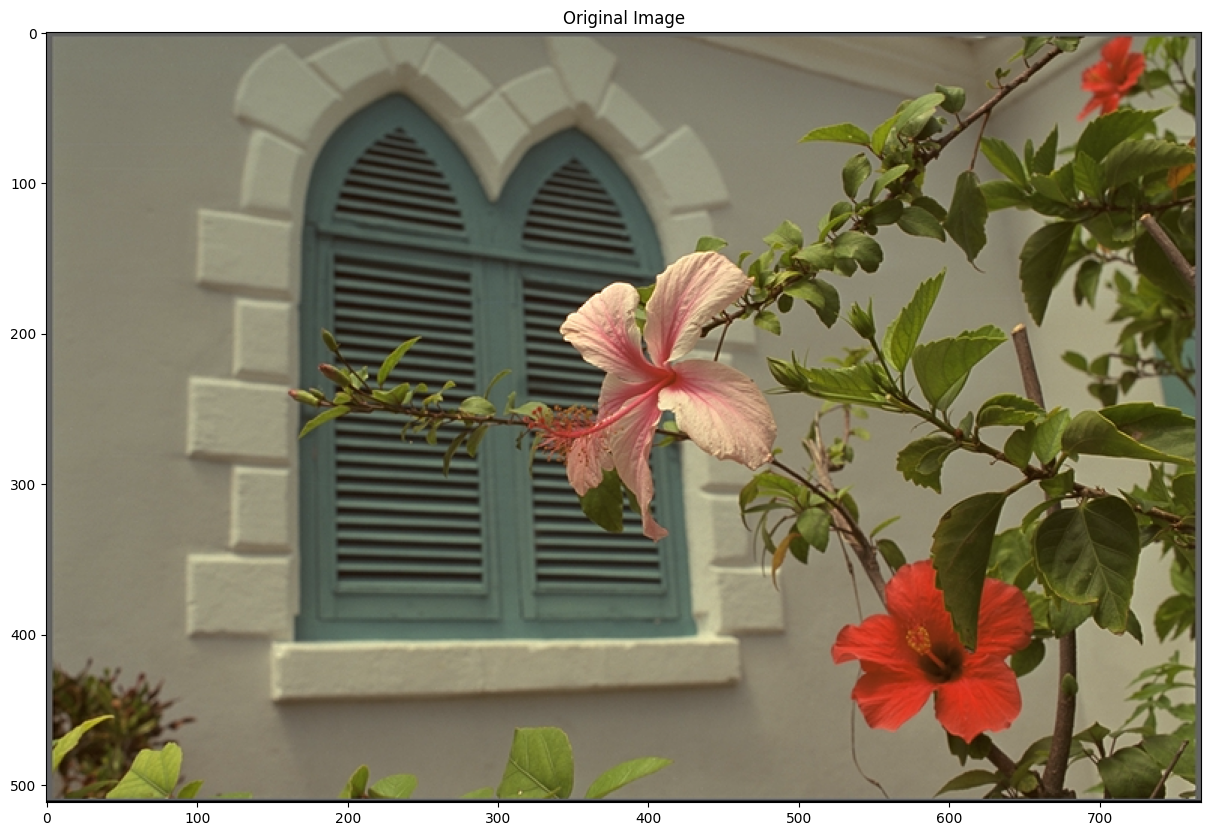

In [2]:
img = cv2.imread('../data/kodim07.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.show()

## 2. Blur Filter
Using a 5x5 Gaussian kernel.

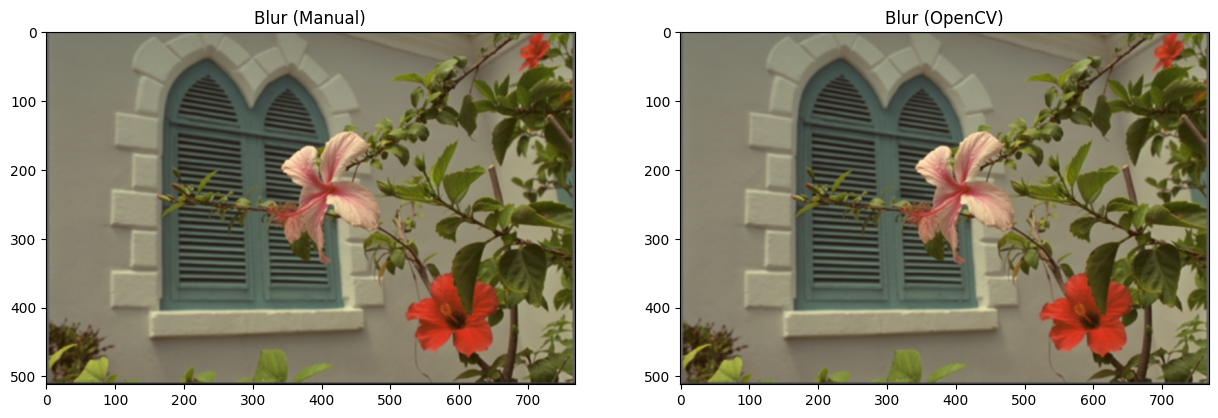

In [3]:
# 5x5 Gaussian Kernel (approximate)
kernel_blur = np.array([
    [1, 4, 7, 4, 1],
    [4, 16, 26, 16, 4],
    [7, 26, 41, 26, 7],
    [4, 16, 26, 16, 4],
    [1, 4, 7, 4, 1]
], dtype=np.float32) / 273.0

blur_manual = manual_convolution(img_rgb, kernel_blur)
blur_cv2 = cv2.filter2D(img_rgb, -1, kernel_blur)

plt.subplot(1, 2, 1), plt.imshow(blur_manual), plt.title("Blur (Manual)")
plt.subplot(1, 2, 2), plt.imshow(blur_cv2), plt.title("Blur (OpenCV)")
plt.show()

## 3. Sharpening Filter

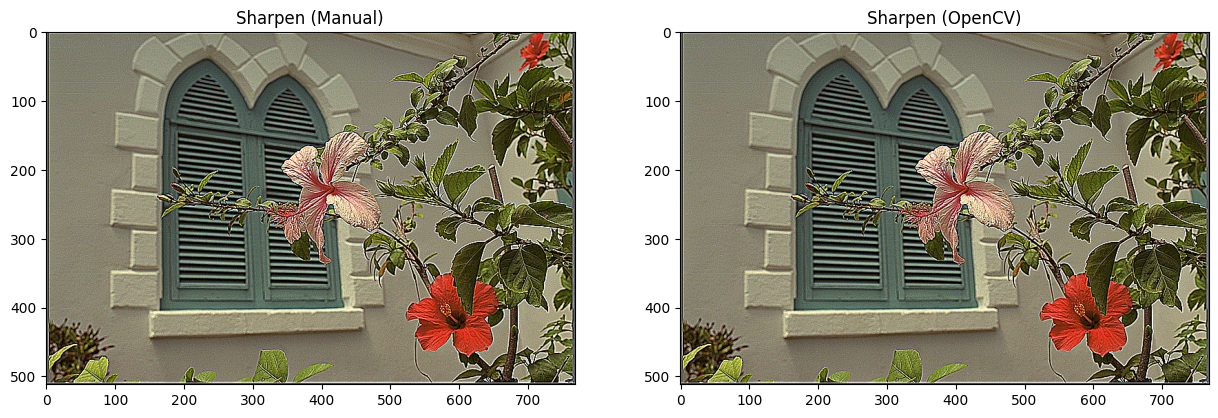

In [4]:
kernel_sharpen = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
], dtype=np.float32)

sharpen_manual = manual_convolution(img_rgb, kernel_sharpen)
sharpen_cv2 = cv2.filter2D(img_rgb, -1, kernel_sharpen)

plt.subplot(1, 2, 1), plt.imshow(sharpen_manual), plt.title("Sharpen (Manual)")
plt.subplot(1, 2, 2), plt.imshow(sharpen_cv2), plt.title("Sharpen (OpenCV)")
plt.show()

## 4. Sobel Filter
For edge detection.

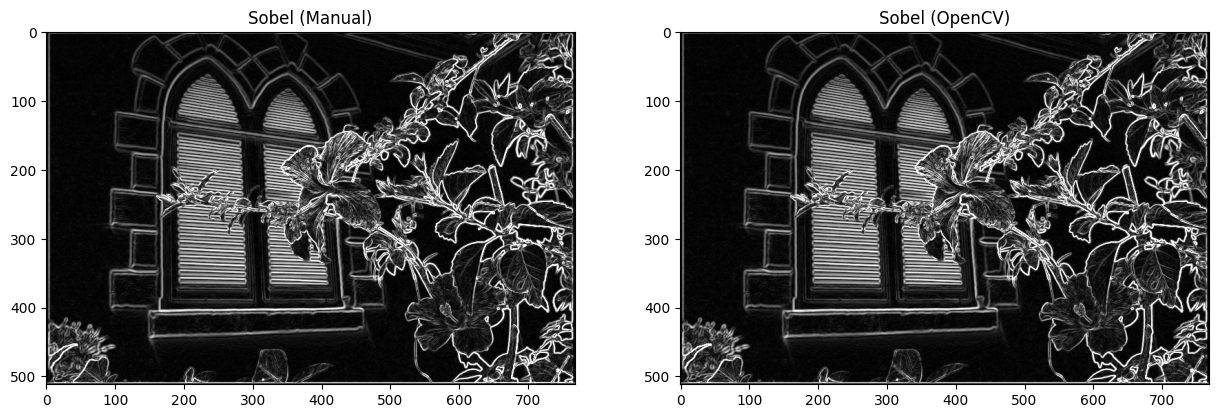

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

grad_x = cv2.filter2D(gray, cv2.CV_32F, sobel_x)
grad_y = cv2.filter2D(gray, cv2.CV_32F, sobel_y)

sobel_manual = np.sqrt(grad_x**2 + grad_y**2)
sobel_manual = np.clip(sobel_manual, 0, 255).astype(np.uint8)

sobel_cv2_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
sobel_cv2_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
sobel_cv2 = np.sqrt(sobel_cv2_x**2 + sobel_cv2_y**2)
sobel_cv2 = np.clip(sobel_cv2, 0, 255).astype(np.uint8)

plt.subplot(1, 2, 1), plt.imshow(sobel_manual, cmap='gray'), plt.title("Sobel (Manual)")
plt.subplot(1, 2, 2), plt.imshow(sobel_cv2, cmap='gray'), plt.title("Sobel (OpenCV)")
plt.show()

## 5. Median Filter
Not a matrix convolution, but described in the assignment.

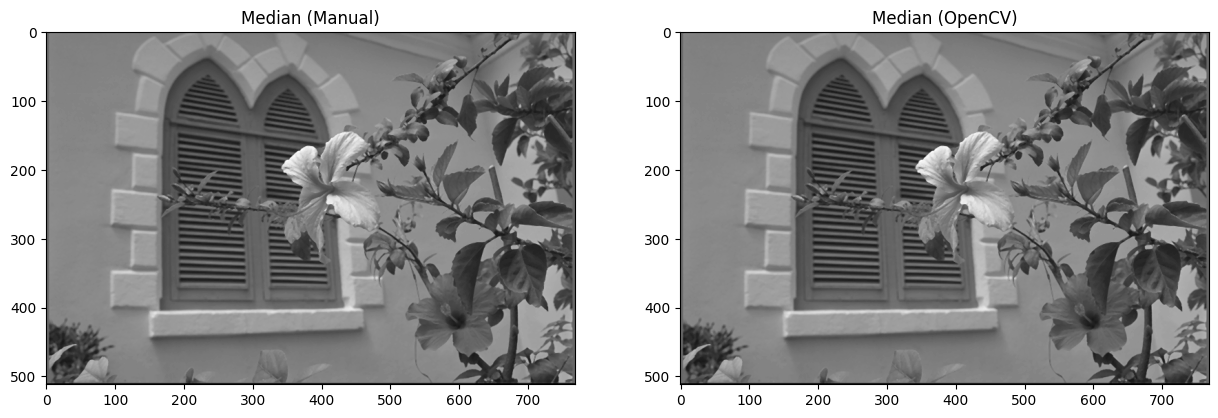

In [6]:
def manual_median(image, size=3):
    img_h, img_w = image.shape[:2]
    pad = size // 2
    padded_img = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    output = np.zeros_like(image)
    
    for i in range(img_h):
        for j in range(img_w):
            region = padded_img[i:i+size, j:j+size]
            output[i, j] = np.median(region)
    return output

median_manual = manual_median(gray, 3)
median_cv2 = cv2.medianBlur(gray, 3)

plt.subplot(1, 2, 1), plt.imshow(median_manual, cmap='gray'), plt.title("Median (Manual)")
plt.subplot(1, 2, 2), plt.imshow(median_cv2, cmap='gray'), plt.title("Median (OpenCV)")
plt.show()